In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/house-prices-advanced-regression-techniques/sample_submission.csv
/kaggle/input/house-prices-advanced-regression-techniques/data_description.txt
/kaggle/input/house-prices-advanced-regression-techniques/train.csv
/kaggle/input/house-prices-advanced-regression-techniques/test.csv


In [2]:
train = pd.read_csv('../input/house-prices-advanced-regression-techniques/train.csv')
test = pd.read_csv('../input/house-prices-advanced-regression-techniques/test.csv')

train.tail()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125
1459,1460,20,RL,75.0,9937,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2008,WD,Normal,147500


In [3]:
test.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [4]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1459 non-null   int64  
 1   MSSubClass     1459 non-null   int64  
 2   MSZoning       1455 non-null   object 
 3   LotFrontage    1232 non-null   float64
 4   LotArea        1459 non-null   int64  
 5   Street         1459 non-null   object 
 6   Alley          107 non-null    object 
 7   LotShape       1459 non-null   object 
 8   LandContour    1459 non-null   object 
 9   Utilities      1457 non-null   object 
 10  LotConfig      1459 non-null   object 
 11  LandSlope      1459 non-null   object 
 12  Neighborhood   1459 non-null   object 
 13  Condition1     1459 non-null   object 
 14  Condition2     1459 non-null   object 
 15  BldgType       1459 non-null   object 
 16  HouseStyle     1459 non-null   object 
 17  OverallQual    1459 non-null   int64  
 18  OverallC

In [5]:
train.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [6]:
train.isna().sum() #checking the missing value of training data

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

In [7]:
train['LotFrontage']= train['LotFrontage'].fillna(train['LotFrontage'].mean())

In [8]:
train.corr()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
Id,1.000000,0.011156,-0.009601,-0.033226,-0.028365,0.012609,-0.012713,-0.021998,-0.050298,-0.005024,...,-0.029643,-0.000477,0.002889,-0.046635,0.001330,0.057044,-0.006242,0.021172,0.000712,-0.021917
MSSubClass,0.011156,1.000000,-0.357056,-0.139781,0.032628,-0.059316,0.027850,0.040581,0.022936,-0.069836,...,-0.012579,-0.006100,-0.012037,-0.043825,-0.026030,0.008283,-0.007683,-0.013585,-0.021407,-0.084284
LotFrontage,-0.009601,-0.357056,1.000000,0.306795,0.234196,-0.052820,0.117598,0.082746,0.179700,0.215828,...,0.077106,0.137454,0.009790,0.062335,0.037684,0.180868,0.001168,0.010158,0.006768,0.334901
LotArea,-0.033226,-0.139781,0.306795,1.000000,0.105806,-0.005636,0.014228,0.013788,0.104160,0.214103,...,0.171698,0.084774,-0.018340,0.020423,0.043160,0.077672,0.038068,0.001205,-0.014261,0.263843
OverallQual,-0.028365,0.032628,0.234196,0.105806,1.000000,-0.091932,0.572323,0.550684,0.411876,0.239666,...,0.238923,0.308819,-0.113937,0.030371,0.064886,0.065166,-0.031406,0.070815,-0.027347,0.790982
OverallCond,0.012609,-0.059316,-0.052820,-0.005636,-0.091932,1.000000,-0.375983,0.073741,-0.128101,-0.046231,...,-0.003334,-0.032589,0.070356,0.025504,0.054811,-0.001985,0.068777,-0.003511,0.043950,-0.077856
YearBuilt,-0.012713,0.027850,0.117598,0.014228,0.572323,-0.375983,1.000000,0.592855,0.315707,0.249503,...,0.224880,0.188686,-0.387268,0.031355,-0.050364,0.004950,-0.034383,0.012398,-0.013618,0.522897
YearRemodAdd,-0.021998,0.040581,0.082746,0.013788,0.550684,0.073741,0.592855,1.000000,0.179618,0.128451,...,0.205726,0.226298,-0.193919,0.045286,-0.038740,0.005829,-0.010286,0.021490,0.035743,0.507101
MasVnrArea,-0.050298,0.022936,0.179700,0.104160,0.411876,-0.128101,0.315707,0.179618,1.000000,0.264736,...,0.159718,0.125703,-0.110204,0.018796,0.061466,0.011723,-0.029815,-0.005965,-0.008201,0.477493
BsmtFinSF1,-0.005024,-0.069836,0.215828,0.214103,0.239666,-0.046231,0.249503,0.128451,0.264736,1.000000,...,0.204306,0.111761,-0.102303,0.026451,0.062021,0.140491,0.003571,-0.015727,0.014359,0.386420


/opt/conda/lib/python3.7/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='SalePrice', ylabel='Density'>

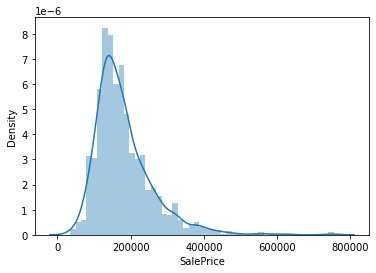

In [9]:
import seaborn as sns
sns.distplot(train['SalePrice'])

In [10]:
test.isna().sum() #checking the missing value of testing data

Id                 0
MSSubClass         0
MSZoning           4
LotFrontage      227
LotArea            0
                ... 
MiscVal            0
MoSold             0
YrSold             0
SaleType           1
SaleCondition      0
Length: 80, dtype: int64

In [11]:
test['LotFrontage'].unique()

array([ 80.,  81.,  74.,  78.,  43.,  75.,  nan,  63.,  85.,  70.,  26.,
        21.,  24., 102.,  94.,  90.,  79., 110., 105.,  41., 100.,  67.,
        60.,  73.,  92.,  84.,  39.,  88.,  25.,  30.,  57.,  68.,  98.,
       120.,  87., 119.,  65.,  56.,  69.,  50.,  53.,  52.,  51.,  72.,
        86., 124.,  44.,  83.,  64.,  82.,  38.,  89.,  35.,  58.,  66.,
        93.,  31.,  76.,  28.,  61.,  95., 129.,  59.,  77.,  96.,  47.,
        34., 117.,  48.,  62.,  42., 106., 112.,  32., 115.,  71.,  45.,
       109., 113., 125., 101., 104., 108., 130., 135.,  36.,  55., 136.,
        97.,  91.,  37.,  22., 103.,  99.,  40., 123.,  54., 107., 150.,
       160., 195., 128.,  33., 118., 134., 155., 126.,  46., 149., 200.,
       121., 131., 114.,  49., 133., 140.])

In [12]:
test['LotFrontage'].nunique()

115

In [13]:
test['LotFrontage']= test['LotFrontage'].fillna(test['LotFrontage'].mean())

In [14]:
test.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
count,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1444.000000,1458.000000,...,1458.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000
mean,2190.000000,57.378341,68.580357,9819.161069,6.078821,5.553804,1971.357779,1983.662783,100.709141,439.203704,...,472.768861,93.174777,48.313914,24.243317,1.794380,17.064428,1.744345,58.167923,6.104181,2007.769705
std,421.321334,42.746880,20.561228,4955.517327,1.436812,1.113740,30.390071,21.130467,177.625900,455.268042,...,217.048611,127.744882,68.883364,67.227765,20.207842,56.609763,30.491646,630.806978,2.722432,1.301740
min,1461.000000,20.000000,21.000000,1470.000000,1.000000,1.000000,1879.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000
25%,1825.500000,20.000000,60.000000,7391.000000,5.000000,5.000000,1953.000000,1963.000000,0.000000,0.000000,...,318.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000
50%,2190.000000,50.000000,68.580357,9399.000000,6.000000,5.000000,1973.000000,1992.000000,0.000000,350.500000,...,480.000000,0.000000,28.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000
75%,2554.500000,70.000000,78.000000,11517.500000,7.000000,6.000000,2001.000000,2004.000000,164.000000,753.500000,...,576.000000,168.000000,72.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000
max,2919.000000,190.000000,200.000000,56600.000000,10.000000,9.000000,2010.000000,2010.000000,1290.000000,4010.000000,...,1488.000000,1424.000000,742.000000,1012.000000,360.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000


In [15]:
#dealing with categorical data (foor data train)
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder 
label_encoder= LabelEncoder()

train['Fence']= label_encoder.fit_transform(train['Fence'])
train['SaleType']=label_encoder.fit_transform(train['SaleType'])
train['SaleCondition']=label_encoder.fit_transform(train['SaleCondition'])
train['GarageType']=label_encoder.fit_transform(train['GarageType'])
train['Street']=label_encoder.fit_transform(train['Street'])




In [16]:
#dealing with categorical data (foor testing data)
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder 
label_encoder= LabelEncoder()

test['Fence']= label_encoder.fit_transform(test['Fence'])
test['SaleType']=label_encoder.fit_transform(test['SaleType'])
test['SaleCondition']=label_encoder.fit_transform(test['SaleCondition'])
test['GarageType']=label_encoder.fit_transform(test['GarageType'])
test['Street']=label_encoder.fit_transform(test['Street'])

test['Fence']

0       2
1       4
2       2
3       4
4       4
       ..
1454    4
1455    4
1456    4
1457    2
1458    4
Name: Fence, Length: 1459, dtype: int64

In [17]:
import seaborn as sns 


In [18]:
# We select some numerical and categorical parameter to be put in multilinear equation
#the parameters that we choose were table : 1,3,4,5,49,50, 51, 56, 58, 61, 62, 71, 73, so on

data_train = train.iloc[:, [1,3,4,5,17,18,19,20,26,34,36,37,38,43,44,45,46, 47, 48,49,50,51,52,54,56,59,61,62,67,68,69,71,75,76,77,78,79]].values

data_test = test.iloc[:, [1,3,4,5,17,18,19,20,26,36,37,38,34,43,44,45,46,47, 48, 49,50,51,52,54,56,59,61,62,67,68,69,71,75,76,77,78,79]].values

**First thing first, I want to evaluate model that we use to predict the house price, since the data type is estimation with several independent variables, so I will use Multiple Linear Regresssion, I will evaluate the data trajn first**

In [19]:
from sklearn.model_selection import train_test_split

In [20]:
y_train= train['SalePrice']
y_train.sum #y train is the real house price

<bound method NDFrame._add_numeric_operations.<locals>.sum of 0       208500
1       181500
2       223500
3       140000
4       250000
         ...  
1455    175000
1456    210000
1457    266500
1458    142125
1459    147500
Name: SalePrice, Length: 1460, dtype: int64>

In [21]:
data_train

array([[6.000e+01, 6.500e+01, 8.450e+03, ..., 2.008e+03, 8.000e+00,
        4.000e+00],
       [2.000e+01, 8.000e+01, 9.600e+03, ..., 2.007e+03, 8.000e+00,
        4.000e+00],
       [6.000e+01, 6.800e+01, 1.125e+04, ..., 2.008e+03, 8.000e+00,
        4.000e+00],
       ...,
       [7.000e+01, 6.600e+01, 9.042e+03, ..., 2.010e+03, 8.000e+00,
        4.000e+00],
       [2.000e+01, 6.800e+01, 9.717e+03, ..., 2.010e+03, 8.000e+00,
        4.000e+00],
       [2.000e+01, 7.500e+01, 9.937e+03, ..., 2.008e+03, 8.000e+00,
        4.000e+00]])

In [22]:
#Dealing with missing value for training data
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
imputer.fit(data_train)
data_train = imputer.transform(data_train)

In [23]:
X_train, Xtest, y_training, y_test = train_test_split(data_train, y_train, test_size=0.25)

In [24]:
from sklearn import linear_model
regr=linear_model.LinearRegression()
regr.fit(X_train,y_training)

LinearRegression()

In [25]:
y_prediction= regr.predict(Xtest)
y_prediction

array([117250.92931987, 151884.82771111, 283926.55980839, 229927.981478  ,
       173315.05717918, 205820.26756309,  91489.14384557, 150832.19690617,
       221930.47925626, 157367.66770359, 291834.72546297, 202970.5783006 ,
       173098.99367509, 135057.05333016, 246497.88799883, 140546.01994322,
       191864.38675813, 166037.11827583, 214087.36219337, 166783.08394314,
        90611.04835925, 219513.78878526, 232687.15481035, 121688.99597601,
       115464.18709462, 203369.98452464, 136754.60242317, 319607.12546663,
       170788.89818037, 149001.46495964, 145499.94041856, 147077.38507786,
       279633.66305186, 131425.72371063, 276638.70043482, 140995.78560238,
       112568.21998637, 132576.95137064, 292613.83520344, 223059.21691253,
       127848.87780994, 112824.43474386, 230654.36425556, 216239.77907503,
       265578.1598824 , 286384.96694746, 254677.61306016, 148711.61412345,
        85680.13756253, 127882.24013207, 315507.38906877, 159913.58414189,
       149867.13037902, 1

In [26]:
mse=np.square(np.subtract(y_test,y_prediction)).mean()
rmse=np.sqrt(mse)/1000
rmse

46.181929044799354

In [27]:
(y_test, y_prediction)

(1378     83000
 292     131000
 35      309000
 667     193500
 252     173000
          ...  
 1194    158000
 1237    195000
 999     206000
 473     440000
 1302    290000
 Name: SalePrice, Length: 365, dtype: int64,
 array([117250.92931987, 151884.82771111, 283926.55980839, 229927.981478  ,
        173315.05717918, 205820.26756309,  91489.14384557, 150832.19690617,
        221930.47925626, 157367.66770359, 291834.72546297, 202970.5783006 ,
        173098.99367509, 135057.05333016, 246497.88799883, 140546.01994322,
        191864.38675813, 166037.11827583, 214087.36219337, 166783.08394314,
         90611.04835925, 219513.78878526, 232687.15481035, 121688.99597601,
        115464.18709462, 203369.98452464, 136754.60242317, 319607.12546663,
        170788.89818037, 149001.46495964, 145499.94041856, 147077.38507786,
        279633.66305186, 131425.72371063, 276638.70043482, 140995.78560238,
        112568.21998637, 132576.95137064, 292613.83520344, 223059.21691253,
        127848.8778

In [28]:
data_test

array([[2.0000e+01, 8.0000e+01, 1.1622e+04, ..., 2.0100e+03, 8.0000e+00,
        4.0000e+00],
       [2.0000e+01, 8.1000e+01, 1.4267e+04, ..., 2.0100e+03, 8.0000e+00,
        4.0000e+00],
       [6.0000e+01, 7.4000e+01, 1.3830e+04, ..., 2.0100e+03, 8.0000e+00,
        4.0000e+00],
       ...,
       [2.0000e+01, 1.6000e+02, 2.0000e+04, ..., 2.0060e+03, 8.0000e+00,
        0.0000e+00],
       [8.5000e+01, 6.2000e+01, 1.0441e+04, ..., 2.0060e+03, 8.0000e+00,
        4.0000e+00],
       [6.0000e+01, 7.4000e+01, 9.6270e+03, ..., 2.0060e+03, 8.0000e+00,
        4.0000e+00]])

In [29]:
#Dealing with missing value for testing data
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
imputer.fit(data_test)
data_test = imputer.transform(data_test)

# **we're going to use multiple linear regression to predict the house prices**

In [30]:
#x_train, x_test, y_tr = train_tet_split(data_train, data_test,y_train)
regr.fit(data_train,y_train)
y_prediction_test=regr.predict(data_test)
y_prediction_test

array([101370.26416885, 135417.02742904, 162014.81705943, ...,
       138089.76551616,  93797.39972481, 241607.72319801])

In [31]:
my_submission = pd.DataFrame({'Id': test["Id"], 'SalePrice' : y_prediction_test.ravel()})

my_submission.to_csv('submission.csv', index=False)